In [15]:
import numpy as np # Version 2.4.3
import h5py # Version 3.15.1
import os

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt # Version 3.10.8
from helpers.config import *
from pycbc.waveform import get_fd_waveform, get_td_waveform # Version 2.10.0

from lisagwresponse import ResponseFromStrain # Version 2.5.0
from lisaglitch import IntegratedShapeletGlitch # Version 2.0.0
from lisainstrument import Instrument # Version 2.1.0

from pytdi.michelson import X2, Y2, Z2 # Version 2.1.0
from pytdi import Data

from gwpy.timeseries import TimeSeries # Version 4.0.1
from scipy.interpolate import interp1d, RectBivariateSpline # Version 1.17.1

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## What are we simulating?

The Laser Interferometer Space Antenna (LISA) consists of three spacecraft exchanging laser beams over million-kilometer baselines. Gravitational waves induce tiny fluctuations in the proper distances between freely falling test masses hosted inside each spacecraft.

Each spacecraft contains two optical benches, each equipped with:

1. a laser and telescope for transmitting/receiving light,
2. a freely falling test mass,
3. and three interferometers.

### Inter-spacecraft Interferometer (ISI)

The inter-spacecraft interferometer compares the incoming laser from a distant spacecraft with the local laser.

This produces beat notes that encode fluctuations in the separation between distant optical benches.

### Test Mass Interferometer (TMI)

The test mass interferometer reflects part of the local laser off the onboard test mass and compares it to a reference beam.

This measures the displacement of the test mass relative to its host spacecraft.

### Reference Interferometer (RFI)

The reference interferometer compares the transmitted laser with a reference beam.

This allows tracking and calibration of intrinsic laser phase noise.

### Simulated Outputs

The primary outputs of a LISA simulation are time series of beat-note fluctuations from:

1. Inter-spacecraft interferometers (ISI)
2. Test mass interferometers (TMI)
3. Reference interferometers (RFI)

Since each spacecraft hosts two of each interferometer, the full constellation produces:

$
3 \text{ spacecraft} \times 2 \text{ benches} \times 3 \text{ interferometers}
= 18 \text{ time series}
$

These measurements are later combined using Time Delay Interferometry (TDI) to suppress laser noise and produce the science data channels.

### Naming Convention

We label spacecraft by $\mathrm{SC}_i$ with $i \in \{1,2,3\}$. Each spacecraft hosts two optical benches labeled $\mathrm{OB}_{ij}$, where the second index denotes the distant spacecraft connected by that optical bench. For example, $\mathrm{OB}_{12}$ is the optical bench on $\mathrm{SC}_1$ communicating with $\mathrm{SC}_2$.

Similarly, the interferometers and test masses associated with a given optical bench inherit the same indices:

1. $\mathrm{ISI}_{ij}$: inter-spacecraft interferometer,
2. $\mathrm{TMI}_{ij}$: test mass interferometer,
3. $\mathrm{RFI}_{ij}$: reference interferometer,
4. $\mathrm{TM}_{ij}$: test mass.

This notation makes it straightforward to identify both the host spacecraft and the optical link associated with any measurement channel.

## Setting up the simulation

In [ ]:
# Open the orbit file and extract metadata describing the orbit sampling
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']      # Initial time of orbit file
    orb_size = orb.attrs['size']  # Number of orbit samples
    orb_dt = orb.attrs['dt']      # Time spacing between orbit samples

# Total duration covered by the orbit file
orb_duration = orb_size * orb_dt

# Pipeline configuration dictionary
pipe = {
    # Start simulation slightly after the orbit file begins
    't0': orb_t0 + 0.01 * orb_duration,

    # Simulation cadence (seconds)
    'dt': 0.25,

    # Total number of simulation samples (10 hours)
    'size': int(10 * 3600 / 0.25),

    # Noise sources retained in the simulation
    # (laser noise excluded assuming ideal TDI cancellation)
    'keep_noises': ['test-mass', 'oms']
}

# Gravitational-wave source configuration
gws = [{
    'type': 'BinaryInspiralGW',  # Massive black hole inspiral
    'm1': 1e5,                  # Primary mass (solar masses)
    'm2': 1e5,                  # Secondary mass (solar masses)
    'd': 1e4,                   # Luminosity distance (Mpc)
    'spin1': 0,                 # Dimensionless spin of primary
    'spin2': 0,                 # Dimensionless spin of secondary
    't_inj': 5*3600,            # GW injection time
    'domain': 'freq',           # Generate waveform in frequency domain
    'gw_beta': 0,               # Ecliptic latitude
    'gw_lambda': 0              # Ecliptic longitude
}]

# Glitch configuration
glitches = [{
    'type': 'IntegratedShapeletGlitch',  # Shapelet-based glitch model
    't_inj': 6*3600,              # Glitch injection time
    'beta': 50,                          # Glitch duration parameter
    'level': 5e-11,                      # Glitch amplitude
    'inj_point': 'tm_12'                 # Inject into test mass TM_12
}]

## Defining your transients

In [4]:
class BinaryInspiralGW(ResponseFromStrain):
    """Represents a GW resulting from a binary merger.
    """
    def __init__(self, m1, m2, d, t_inj, spin1=0.0, spin2=0.0, domain='freq', **kwargs,) -> None:
        super().__init__(**kwargs)
        self.t_inj = float(t_inj)
        self.m1 = float(m1)
        self.m2 = float(m2)
        self.d = float(d)
        self.spin1 = float(spin1)
        self.spin2 = float(spin2)
        self.domain = domain
        self.f_lower = self.compute_flower()

        if self.domain == 'time':
            hp_td, hc_td = get_td_waveform(approximant="IMRPhenomXHM",
                mass1=self.m1, mass2=self.m2, delta_t=1e-3/self.f_lower, f_lower=self.f_lower, 
                                           distance=self.d, spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_td
            self.hc = hc_td
            
        elif self.domain == 'freq':
            hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM",
                                       mass1=self.m1, mass2=self.m2, delta_f=self.f_lower/1e3,
                                       f_lower=self.f_lower, distance=self.d, 
                                           spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_fd.to_timeseries()
            self.hc = hc_fd.to_timeseries()
        self.amp_hp = max(self.hp)
        self.amp_hc = max(self.hc)
        self.duration = self.compute_duration()

    def compute_flower(self) -> float:
        c = 3e8
        G = 6.67e-11
        M = (self.m1 + self.m2)*2e30
        r = 6
        return (c**3)/(((6*r)**1.5)*np.pi*G*M)

    def compute_duration(self) -> float:
        """compute an approximate duration for the gw"""
        h = np.sqrt(self.hp**2 + self.hc**2)
        threshold = max(h)/30
        
        mask = h >= threshold
        duration = np.sum(mask) * 0.25
        
        return duration

    def compute_hplus(self, t) -> np.ndarray:
        return self.compute_signal(self.hp, self.amp_hp, t)

    def compute_hcross(self, t) -> np.ndarray:
        return self.compute_signal(self.hc, self.amp_hc, t)

    def compute_signal(self, h, amp, t):
        h.start_time = 0
        peak_time = h.sample_times[np.where(np.array(h) == amp)][0]
        delta_t = self.t_inj - t[0] - 405
        h = h.cyclic_time_shift(-(peak_time - delta_t))
        h.start_time = 0
        
        mask1 = h.sample_times < delta_t + 20000
        sigslice = h[mask1]
        tslice = h.sample_times[mask1]
        tslice = tslice + t[0]
        f = interp1d(tslice, sigslice, 
                         bounds_error=False, fill_value=0)
        return f(t)

In [ ]:
# Extract gravitational-wave source configuration
gw = gws[0]

# Initialize binary inspiral GW object
gw = BinaryInspiralGW(
    m1=gw['m1'],                  # Primary mass (solar masses)
    m2=gw['m2'],                  # Secondary mass (solar masses)
    d=gw['d'],                    # Luminosity distance (Mpc)

    # Injection time shifted into absolute simulation coordinates
    t_inj=gw['t_inj'] + pipe['t0'],

    spin1=gw['spin1'],            # Primary spin
    spin2=gw['spin2'],            # Secondary spin

    # Sky location of source
    gw_beta=gw['gw_beta'],
    gw_lambda=gw['gw_lambda'],

    # Orbit file used to compute detector response
    orbits=orbits_path
)

# Remove old GW file if it already exists
if os.path.exists(gw_path):
    os.remove(gw_path)

# Generate and save GW response time series
gw.write(
    path=gw_path,
    mode="a",
    dt=pipe['dt'],      # Simulation cadence
    size=pipe['size'],  # Number of samples
    t0=pipe['t0']       # Simulation start time
)

# Extract glitch configuration
glitch = glitches[0]

# Initialize shapelet glitch model
glitch = IntegratedShapeletGlitch(
    level=glitch['level'],            # Glitch amplitude
    beta=glitch['beta'],              # Duration parameter
    inj_point=glitch['inj_point'],    # Injection channel/location

    # Injection time shifted into simulation coordinates
    t_inj=glitch['t_inj'] + pipe['t0']
)

# Remove old glitch file if it already exists
if os.path.exists(glitch_path):
    os.remove(glitch_path)

# Generate and save glitch time series
glitch.write(
    path=glitch_path,
    mode="a",
    dt=pipe['dt'],
    t0=pipe['t0'],
    size=pipe['size']
)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
/var/folders/v8/0j17mq8904qfdtqgvchw9sxm0000gn/T/ipykernel_22040/1618777181.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  peak_time = h.sample_times[np.where(np.array(h) == amp)][0]


You are using an orbit file in a version that might not be fully supported


0.0014913319255237568


/var/folders/v8/0j17mq8904qfdtqgvchw9sxm0000gn/T/ipykernel_22040/1618777181.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  peak_time = h.sample_times[np.where(np.array(h) == amp)][0]


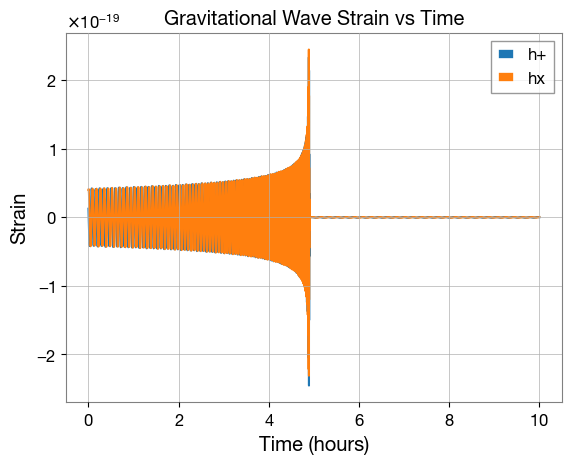

In [10]:
# Extract gravitational-wave source configuration
gw = gws[0]

# Initialize binary inspiral GW object
gw = BinaryInspiralGW(
    m1=gw['m1'],                  # Primary mass (solar masses)
    m2=gw['m2'],                  # Secondary mass (solar masses)
    d=gw['d'],                    # Luminosity distance (Mpc)

    # Injection time shifted into absolute simulation coordinates
    t_inj=gw['t_inj'],

    spin1=gw['spin1'],            # Primary spin
    spin2=gw['spin2'],            # Secondary spin

    # Sky location of source
    gw_beta=gw['gw_beta'],
    gw_lambda=gw['gw_lambda'],

    # Orbit file used to compute detector response
    orbits=orbits_path
)
print(gw.compute_flower())
t = np.arange(0, 10*3600, 0.25)
plt.plot(t/3600, gw.compute_hplus(t), label='h+')
plt.plot(t/3600, gw.compute_hcross(t), label='hx')
plt.xlabel('Time (hours)')
plt.ylabel('Strain')
plt.title('Gravitational Wave Strain vs Time')
plt.legend()
plt.show()

The function used to describe glitches expected in LISA are the Integrated Shapelet models given below:

$$\dfrac{\Delta \nu (t)}{\nu_0} = \dfrac{2A\beta}{c}\Big(1-e^{-\frac{t-t_{\text{inj}}}{\beta}}\Big(\dfrac{t-t_{\text{inj}}}{\beta}-1\Big)\Big)\Theta\Big(\dfrac{t-t_{\text{inj}}}{\beta}\Big)$$

where $A$ is also referred to as the amplitude, $\beta$ is the glitch timescale, $t_{\text{inj}}$ is the injection time, $\Delta \nu (t)$ is the beatnote frequency, $\nu_0=2.816\cdot 10^{14}$ Hz is the nominal laser frequency and $c$ is the speed of light. The quantity $2A\beta$ is also called the *level* and is an input parameter in glitch model functions in Python.

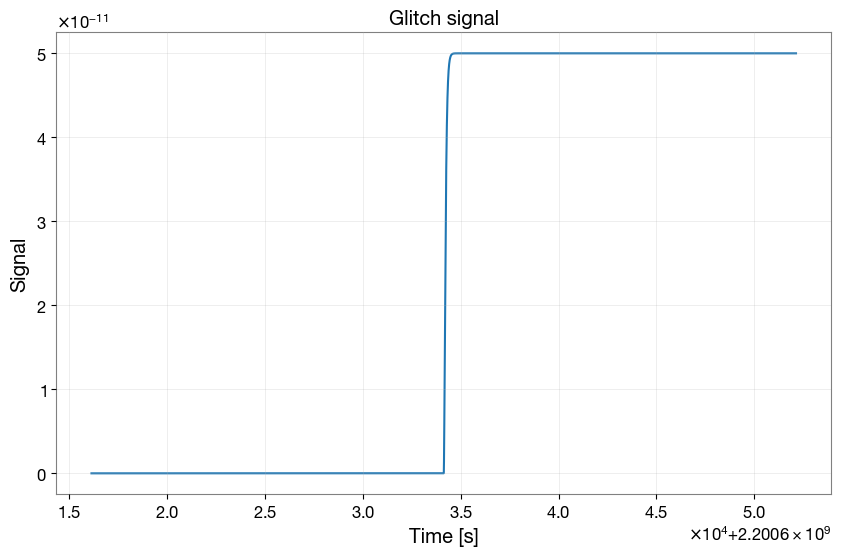

In [14]:
glitch = glitches[0]

# Initialize shapelet glitch model
glitch = IntegratedShapeletGlitch(
    level=glitch['level'],            # Glitch amplitude
    beta=glitch['beta'],              # Duration parameter
    inj_point=glitch['inj_point'],    # Injection channel/location

    # Injection time shifted into simulation coordinates
    t_inj=glitch['t_inj'] + pipe['t0']
)

t = np.arange(0, 10*3600, 0.25) + pipe['t0']
glitch.plot(t)

## Running the simulation

In [11]:
# Initialize LISA instrument simulation
lisa_instrument = Instrument(
    size=pipe['size'],        # Number of simulation samples
    dt=pipe['dt'],            # Simulation cadence
    t0=pipe['t0'],            # Simulation start time

    # Orbit configuration describing spacecraft motion
    orbits=orbits_path,

    # Injected transient files
    glitches=glitch_path,
    gws=gw_path,

    # Random seed for reproducibility
    seed=42
)

# Disable all noise sources except those explicitly retained
lisa_instrument.disable_all_noises(pipe['keep_noises'])

# Remove previous simulation output if it exists
if os.path.exists(simulation_path):
    os.remove(simulation_path)

# Generate and save simulated interferometer measurements
lisa_instrument.write(simulation_path)

# Load simulation output into a convenient data object
data = Data.from_instrument(simulation_path)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


## Time Delay Interferometry (TDI)

In [12]:
channel = X2
tdi_data = channel.build(**data.args)(data.measurements)
signal = TimeSeries(tdi_data, t0=pipe['t0'], dt=pipe['dt'])

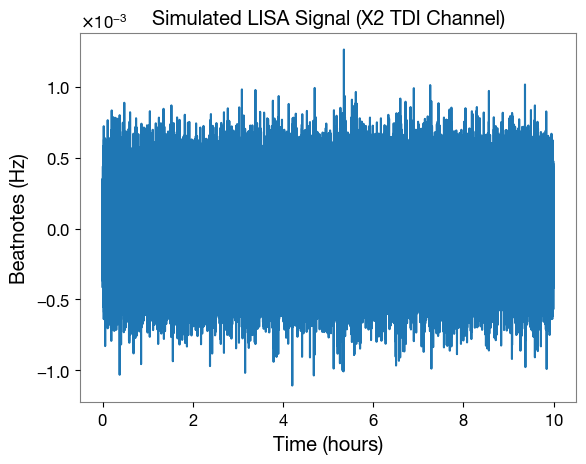

In [13]:
times = signal.times.value - pipe['t0']  # Convert to seconds since the start of the simulation

plt.plot(times/3600, signal.value)
plt.xlabel('Time (hours)')
plt.ylabel('Beatnotes (Hz)')
plt.title('Simulated LISA Signal (X2 TDI Channel)')
plt.grid()
plt.show()

## Viewing the transients

In [16]:
def generate_ft_arr(frange, trange, Q):
    """
    Generate adaptive frequency and time grids for the Q-transform.

    Frequency spacing scales with f/Q while time spacing scales with Q/f,
    ensuring approximately constant time-frequency resolution.
    """

    # Frequency and time bounds
    fmin, fmax = frange
    tmin, tmax = trange

    # Construct adaptive frequency grid
    f = fmin
    f_arr = [fmin]

    while f <= fmax:
        # Frequency step proportional to bandwidth
        f = f + (f / Q) * (2 * np.sqrt(2))
        f_arr.append(f)

    # Construct corresponding adaptive time grids
    t_arr = []

    for f in f_arr:

        t = tmin
        tslice = [tmin]

        while t <= tmax:

            # Time resolution determined by Gaussian width
            t = t + (Q / f) * (1 / (np.sqrt(2) * np.pi))

            tslice.append(t)

        t_arr.append(tslice)

    return f_arr, t_arr


def q_transform(times, signal, Q, frange, trange, resolution):
    """
    Compute the Q-transform of a signal using Gaussian-windowed
    complex exponentials.
    """

    # Generate adaptive frequency/time sampling grids
    f_arr, t_arr = generate_ft_arr(frange, trange, Q)

    QT = []

    # Loop over frequencies
    for i, f in enumerate(f_arr):

        t_slice = t_arr[i]
        out_slice = []

        # Loop over time centers
        for t in t_slice:

            # Characteristic width of Gaussian window
            tau = Q / (np.sqrt(2) * np.pi * f)

            # Select local signal segment around current time-frequency tile
            seg = np.where(
                (times > t - 4 * tau) &
                (times < t + 4 * tau)
            )[0]

            timeseg = times[seg]
            sigseg = signal[seg]

            # Apply Hann taper to reduce edge effects
            sigseg = sigseg * np.hanning(len(sigseg))

            # Construct Gaussian-modulated sinusoidal window
            window = (
                np.exp(-0.5 * ((timeseg - t) / tau) ** 2)
                * np.exp(-2j * np.pi * f * (timeseg - t))
            )

            # Normalize window power
            window /= np.sqrt(np.sum(np.abs(window) ** 2))

            # Compute Q-transform coefficient magnitude
            out_slice.append(np.abs(np.sum(sigseg * window)))

        # Interpolate each frequency slice onto common time grid
        try:
            f = interp1d(
                t_slice,
                out_slice,
                kind='cubic',
                fill_value='extrapolate'
            )

        except:
            f = interp1d(
                t_slice,
                out_slice,
                kind='linear',
                fill_value='extrapolate'
            )

        QT.append(f(t_arr[-1]))

    # Convert to NumPy array
    QT = np.array(QT)

    # Normalize each frequency row by its median
    QT /= np.median(QT, axis=1, keepdims=True)

    # Rescale so median corresponds to log(2)
    QT *= np.log(2)

    # Construct final uniform interpolation grids
    f_new = np.logspace(
        np.log10(np.min(f_arr)),
        np.log10(np.max(f_arr)),
        resolution,
        endpoint=True
    )

    t_new = np.linspace(
        np.min(t_arr[-1]),
        np.max(t_arr[-1]),
        resolution,
        endpoint=True
    )

    # Interpolate Q-transform onto uniform image grid
    cubicspline = RectBivariateSpline(
        f_arr,
        t_arr[-1],
        QT,
        kx=3,
        ky=3
    )

    QTnew = cubicspline(f_new, t_new)

    # Prevent non-positive interpolation artefacts
    QTnew = np.clip(QTnew, 1e-12, None)

    return t_new, f_new, QTnew


def generate_qscan(signal, pipe, t_inj,
                   frange, trange, Q, resolution):
    """
    Generate a Q-transform spectrogram centered around
    a transient injection time.
    """

    # Convert signal into GWPy TimeSeries object
    signal = TimeSeries(signal, dt=pipe['dt'], t0=0)

    # Extract time arrays
    time_secs = signal.times.value
    time_hrs = time_secs / 3600

    # Injection time
    tevent = t_inj

    # Select time window around transient
    index = np.where(
        (time_hrs <= tevent / 3600 + trange[1]) &
        (time_hrs >= tevent / 3600 + trange[0])
    )[0]

    # Extract local signal segment
    sigslice = signal[index].value
    timeslice = signal[index].times.value

    # Compute Q-transform
    t_arr, f_arr, QT = q_transform(
        timeslice,
        sigslice,
        Q=Q,
        resolution=resolution,
        frange=frange,
        trange=(np.min(timeslice), np.max(timeslice))
    )

    return t_arr, f_arr, QT

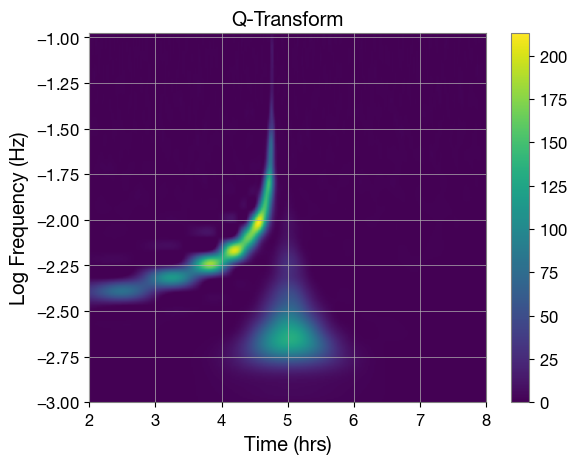

In [17]:
# Generate a Q-transform spectrogram centered on the GW injection time
t_arr, f_arr, QT = generate_qscan(
    signal,
    pipe,
    gws[0]['t_inj'],     # Injection time of GW transient

    resolution=256,      # Final image resolution

    # Frequency range displayed in spectrogram
    frange=(1e-3, 1e-1),

    # Time window around transient (hours)
    trange=(-3, 3),

    # Quality factor controlling time-frequency resolution
    Q=15
)

# Display Q-transform as an image
plt.imshow(
    QT,

    # Map pixel coordinates to physical time/frequency axes
    extent=[
        np.min(t_arr) / 3600,
        np.max(t_arr) / 3600,
        np.min(np.log10(f_arr)),
        np.max(np.log10(f_arr))
    ],

    aspect='auto',
    origin='lower'
)

# Axis labels
plt.ylabel('Log Frequency (Hz)')
plt.xlabel('Time (hrs)')

# Figure title
plt.title('Q-Transform')

# Display color scale corresponding to Q-transform amplitude
plt.colorbar()

plt.show()